In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder

def drop_pciat_data(file_name, output_name):
    # Load the dataset
    df = pd.read_csv(file_name)
    
    # Identify all columns related to PCIAT (case-sensitive)
    pciat_cols = [col for col in df.columns if 'PCIAT' in col]
    
    print(f"File: {file_name}")
    print(f"Dropping {len(pciat_cols)} columns: {pciat_cols}")
    
    # Drop the columns
    df_cleaned = df.drop(columns=pciat_cols)
    
    # Save the cleaned file
    df_cleaned.to_csv(output_name, index=False)
    print(f"Successfully saved to: {output_name}\n")

# Run for your split files
drop_pciat_data('data/prepared_splits/train_split.csv', 'data/prepared_splits/train_split_cleaned.csv')
drop_pciat_data('data/prepared_splits/test_split.csv', 'data/prepared_splits/test_split_cleaned.csv')

File: data/prepared_splits/train_split.csv
Dropping 22 columns: ['PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total']
Successfully saved to: data/prepared_splits/train_split_cleaned.csv

File: data/prepared_splits/test_split.csv
Dropping 22 columns: ['PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total']
Successf

In [ ]:
# 1. Load the cleaned data
train = pd.read_csv('data/prepared_splits/train_split_cleaned.csv')
test = pd.read_csv('data/prepared_splits/test_split_cleaned.csv')

# 2. Preprocessing
# Drop 'id' as it's not a feature
X_train = train.drop(columns=['id', 'sii'])
y_train = train['sii']
X_test = test.drop(columns=['id', 'sii'])
y_test = test['sii']

# Identify and Encode Categorical Columns (Seasons)
cat_cols = X_train.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    # Combine train and test to ensure consistent encoding
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# 3. Train the Model
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

# 4. Predict and Evaluate
preds = model.predict(X_test)

# Calculate Quadratic Weighted Kappa
qwk = cohen_kappa_score(y_test, preds, weights='quadratic')

print(f"--- Baseline Performance ---")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")

/var/folders/m6/2lgmm8516r37yq5gnyyd84g00000gn/T/ipykernel_63658/3221746330.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


--- Baseline Performance ---
Quadratic Weighted Kappa: 0.3384


/var/folders/m6/2lgmm8516r37yq5gnyyd84g00000gn/T/ipykernel_63658/3039951307.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Starting 5-fold Cross-Validation...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[114]	valid_0's l2: 0.439934
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[53]	valid_0's l2: 0.468489
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[53]	valid_0's l2: 0.481622
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	valid_0's l2: 0.484852
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[84]	valid_0's l2: 0.453532

Cross-Validation Complete.
Optimized CV QWK: 0.4426
Optimal Thresholds: [0.51138056 1.02514432 2.9368529 ]


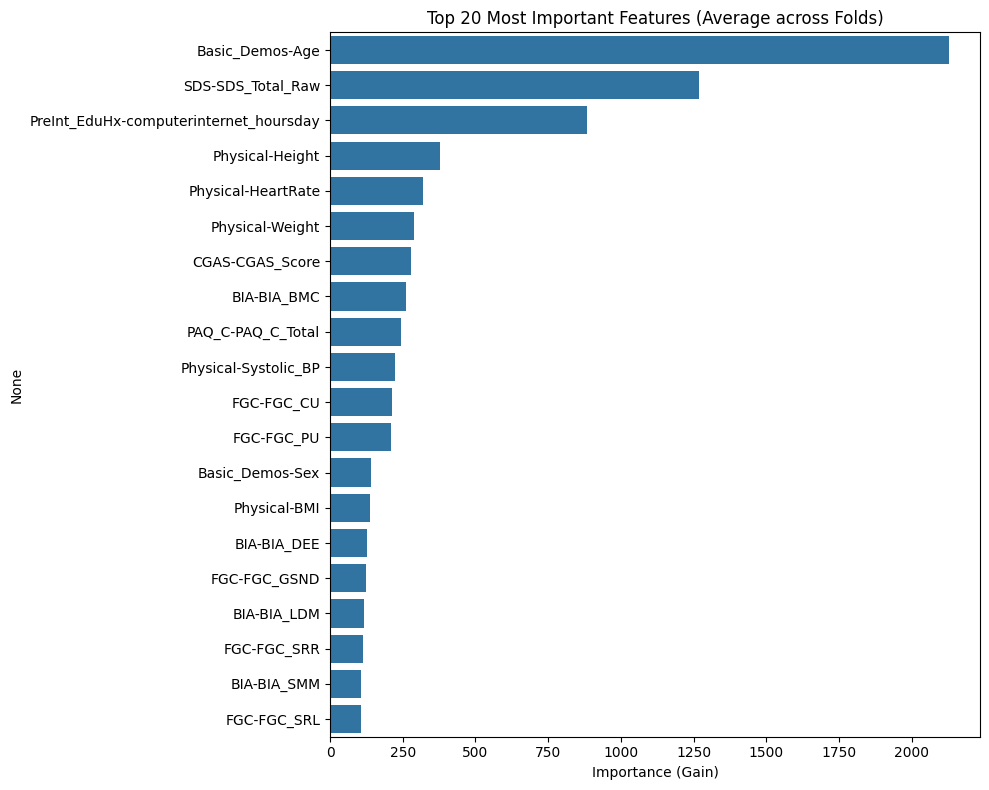

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
import scipy as sp

# 1. LOAD DATA
train = pd.read_csv('data/prepared_splits/train_split_cleaned.csv')
# We will use the train_split as our primary cross-validation set

# 2. PREPROCESSING
def preprocess(df):
    df = df.copy()
    # Drop ID as it's not a feature
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
    
    # Identify categorical columns (usually 'Season' columns)
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    return df, cat_cols

train_processed, cat_features = preprocess(train)
X = train_processed.drop(columns=['sii'])
y = train_processed['sii']

# 3. THRESHOLD OPTIMIZER CLASS
# This class finds the best cut-off points to turn 1.45 into a 1 or 2 to maximize QWK
class OptimizedRounder:
    def __init__(self):
        self.coef_ = [0.5, 1.5, 2.5]

    def _kappa_loss(self, coef, X, y):
        X_p = pd.cut(X, [-np.inf] + list(np.sort(coef)) + [np.inf], labels=[0, 1, 2, 3])
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def fit(self, X, y):
        loss_partial = lambda coef: self._kappa_loss(coef, X, y)
        initial_coef = [0.5, 1.5, 2.5]
        self.coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead').x

    def predict(self, X, coef):
        return pd.cut(X, [-np.inf] + list(np.sort(coef)) + [np.inf], labels=[0, 1, 2, 3])

    def coefficients(self):
        return self.coef_

# 4. CROSS-VALIDATION LOOP
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
feature_importances = pd.DataFrame(index=X.columns)

print(f"Starting {n_splits}-fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Using Regressor instead of Classifier for threshold optimization
    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        random_state=42,
        importance_type='gain',
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    # Store OOF predictions and Importance
    oof_preds[val_idx] = model.predict(X_val)
    feature_importances[f'fold_{fold}'] = model.feature_importances_

print("\nCross-Validation Complete.")

# 5. THRESHOLD OPTIMIZATION
rounder = OptimizedRounder()
rounder.fit(oof_preds, y)
final_coefs = rounder.coefficients()
final_preds = rounder.predict(oof_preds, final_coefs)

cv_qwk = cohen_kappa_score(y, final_preds, weights='quadratic')
print(f"Optimized CV QWK: {cv_qwk:.4f}")
print(f"Optimal Thresholds: {final_coefs}")

# 6. VISUALIZE FEATURE IMPORTANCE
feature_importances['average'] = feature_importances.mean(axis=1)
top_features = feature_importances.sort_values(by='average', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='average', y=top_features.index, data=top_features)
plt.title('Top 20 Most Important Features (Average across Folds)')
plt.xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
import scipy as sp

# 1. FEATURE ENGINEERING FUNCTION
def engineer_features(df):
    df = df.copy()
    
    # Age-normalized physical features
    # These help the model see "outliers" for a specific age
    if 'Physical-Weight' in df.columns and 'Basic_Demos-Age' in df.columns:
        df['weight_per_age'] = df['Physical-Weight'] / (df['Basic_Demos-Age'] + 1)
        df['height_per_age'] = df['Physical-Height'] / (df['Basic_Demos-Age'] + 1)
    
    # Interaction: Internet use vs Age
    if 'PreInt_EduHx-computerinternet_hoursday' in df.columns:
        df['internet_intensity'] = df['PreInt_EduHx-computerinternet_hoursday'] * df['Basic_Demos-Age']
        
    # Aggregate Physical Health Score (Simple sum of normalized BPs)
    if 'Physical-Systolic_BP' in df.columns:
        df['total_bp'] = df['Physical-Systolic_BP'] + df['Physical-Diastolic_BP']
        
    # Create "Missingness" flags for the top-importance columns
    # Sometimes 'NaN' is a feature itself!
    for col in ['Physical-BMI', 'Physical-Height', 'SDS-SDS_Total_T']:
        if col in df.columns:
            df[f'{col}_is_missing'] = df[col].isna().astype(int)
            
    return df

# 2. LOAD AND PREPARE
train = pd.read_csv('data/prepared_splits/train_split_cleaned.csv')
test = pd.read_csv('data/prepared_splits/test_split_cleaned.csv')

train = engineer_features(train)
test = engineer_features(test)

# Encoding categorical seasons
cat_cols = train.select_dtypes(include=['object']).drop(columns=['id'], errors='ignore').columns
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

X = train.drop(columns=['id', 'sii'])
y = train['sii']
X_test_final = test.drop(columns=['id', 'sii'])

# 3. OPTIMIZED REGRESSION LOOP
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test_final))

# Competitive Hyperparameters for LightGBM
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.02,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'max_depth': 8,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params, n_estimators=2000)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100)]
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_test_final) / n_splits

# 4. THRESHOLD OPTIMIZATION (OptimizedRounder from previous step)
# [Assume OptimizedRounder class is defined above]
rounder = OptimizedRounder()
rounder.fit(oof_preds, y)
final_thresholds = rounder.coefficients()

# Final Predictions for your test_split
final_test_preds = rounder.predict(test_preds, final_thresholds)

# 5. GENERATE SUBMISSION-READY OUTPUT
submission = pd.DataFrame({
    'id': test['id'],
    'sii': final_test_preds
})
submission.to_csv('submission.csv', index=False)

print(f"Optimized CV QWK: {cohen_kappa_score(y, rounder.predict(oof_preds, final_thresholds), weights='quadratic'):.4f}")
print(f"Final Thresholds: {final_thresholds}")

/var/folders/m6/2lgmm8516r37yq5gnyyd84g00000gn/T/ipykernel_63658/3908788085.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).drop(columns=['id'], errors='ignore').columns


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[200]	valid_0's rmse: 0.660738
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[122]	valid_0's rmse: 0.681706
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[88]	valid_0's rmse: 0.686163
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[138]	valid_0's rmse: 0.687272
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[122]	valid_0's rmse: 0.670243
Optimized CV QWK: 0.4497
Final Thresholds: [0.60448693 0.95883304 2.71116872]


/var/folders/m6/2lgmm8516r37yq5gnyyd84g00000gn/T/ipykernel_63658/1158454738.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(include=['object']).drop(columns=['id'], errors='ignore').columns:


Starting Ensemble Cross-Validation...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[94]	valid_0's l2: 0.442022
Fold 0 complete.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[53]	valid_0's l2: 0.451821
Fold 1 complete.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[61]	valid_0's l2: 0.479754
Fold 2 complete.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[55]	valid_0's l2: 0.477861
Fold 3 complete.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[95]	valid_0's l2: 0.44081
Fold 4 complete.

--- Final Results ---
Ensemble Optimized QWK: 0.4449
Optimal Thresholds: [0.53148148 1.09444444 2.64351852]


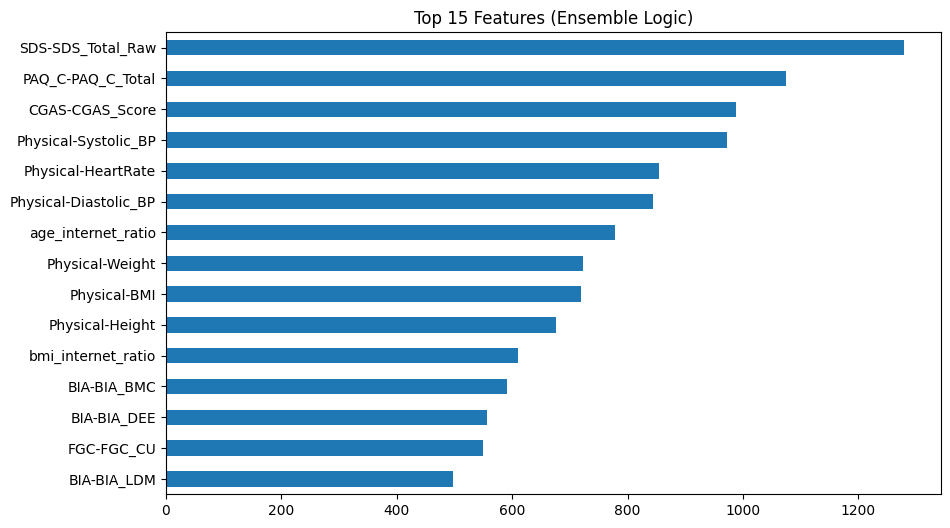

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

# 1. OPTIMIZED ROUNDER CLASS
class OptimizedRounder:
    def __init__(self):
        self.coef_ = [0.5, 1.5, 2.5]

    def _kappa_loss(self, coef, X, y):
        X_p = pd.cut(X, [-np.inf] + list(np.sort(coef)) + [np.inf], labels=[0, 1, 2, 3])
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def fit(self, X, y):
        loss_partial = lambda coef: self._kappa_loss(coef, X, y)
        initial_coef = [0.5, 1.5, 2.5]
        self.coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead').x

    def predict(self, X, coef):
        return pd.cut(X, [-np.inf] + list(np.sort(coef)) + [np.inf], labels=[0, 1, 2, 3])

    def coefficients(self):
        return self.coef_

# 2. ADVANCED FEATURE ENGINEERING
def advanced_engineering(df):
    df = df.copy()
    
    # Interaction: BMI * Internet Use (sedentary behavior proxy)
    if 'Physical-BMI' in df.columns and 'PreInt_EduHx-computerinternet_hoursday' in df.columns:
        df['bmi_internet_ratio'] = df['Physical-BMI'] * df['PreInt_EduHx-computerinternet_hoursday']
    
    # Interaction: Age / (Internet + 1) (Age-adjusted usage)
    if 'Basic_Demos-Age' in df.columns and 'PreInt_EduHx-computerinternet_hoursday' in df.columns:
        df['age_internet_ratio'] = df['Basic_Demos-Age'] / (df['PreInt_EduHx-computerinternet_hoursday'] + 1)

    # Ordinal Mapping for Seasons
    season_map = {'Spring': 0, 'Summer': 1, 'Fall': 2, 'Winter': 3}
    for col in [c for c in df.columns if 'Season' in c]:
        df[col] = df[col].map(season_map).fillna(-1)

    return df

# 3. PREPARE DATA
train = pd.read_csv('data/prepared_splits/train_split_cleaned.csv')
test = pd.read_csv('data/prepared_splits/test_split_cleaned.csv')

train = advanced_engineering(train)
test = advanced_engineering(test)

# Encoding remaining categorical columns
for col in train.select_dtypes(include=['object']).drop(columns=['id'], errors='ignore').columns:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

X = train.drop(columns=['id', 'sii'])
y = train['sii']
X_test_final = test.drop(columns=['id', 'sii'])

# 4. ENSEMBLE CROSS-VALIDATION
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test_final))

print("Starting Ensemble Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Fixed Model A: LightGBM ---
    lgb_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, max_depth=7, random_state=42, verbose=-1)
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
    
    # --- Fixed Model B: XGBoost (Corrected Early Stopping) ---
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000, 
        learning_rate=0.03, 
        max_depth=7, 
        random_state=42,
        early_stopping_rounds=100  # <--- Moved to constructor
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # 50/50 Ensemble Blend
    fold_preds = (lgb_model.predict(X_val) + xgb_model.predict(X_val)) / 2
    oof_preds[val_idx] = fold_preds
    test_preds += (lgb_model.predict(X_test_final) + xgb_model.predict(X_test_final)) / (2 * n_splits)
    print(f"Fold {fold} complete.")

# 5. FINAL OPTIMIZATION & SCORE
rounder = OptimizedRounder()
rounder.fit(oof_preds, y)
final_thresholds = rounder.coefficients()
final_qwk = cohen_kappa_score(y, rounder.predict(oof_preds, final_thresholds), weights='quadratic')

print(f"\n--- Final Results ---")
print(f"Ensemble Optimized QWK: {final_qwk:.4f}")
print(f"Optimal Thresholds: {final_thresholds}")

# 6. FEATURE IMPORTANCE (LightGBM)
lgb_model.fit(X, y) # Fit on full data for importance
feat_imp = pd.Series(lgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh').invert_yaxis()
plt.title('Top 15 Features (Ensemble Logic)')
plt.show()

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
import scipy as sp

# 1. PREPARE THE DATA
# Load your cleaned splits and the unlabeled rows
train = pd.read_csv('data/prepared_splits/train_split_cleaned.csv')
test = pd.read_csv('data/prepared_splits/test_split_cleaned.csv')
unlabeled = pd.read_csv('data/prepared_splits/unlabeled_rows.csv')

# Drop PCIAT from unlabeled just like we did for the others
pciat_cols = [c for c in unlabeled.columns if 'PCIAT' in c.upper()]
unlabeled = unlabeled.drop(columns=pciat_cols)

def full_pipeline_preprocess(df, is_train=True):
    df = df.copy()
    # Feature Engineering
    if 'Physical-BMI' in df.columns and 'PreInt_EduHx-computerinternet_hoursday' in df.columns:
        df['bmi_internet_ratio'] = df['Physical-BMI'] * df['PreInt_EduHx-computerinternet_hoursday']
    
    # Season mapping
    season_map = {'Spring': 0, 'Summer': 1, 'Fall': 2, 'Winter': 3}
    for col in [c for c in df.columns if 'Season' in c]:
        df[col] = df[col].map(season_map).fillna(-1)
        
    return df

train_proc = full_pipeline_preprocess(train)
unlabeled_proc = full_pipeline_preprocess(unlabeled)
X_test_final = full_pipeline_preprocess(test).drop(columns=['id', 'sii'], errors='ignore')

# Encode categoricals
for col in train_proc.select_dtypes(include=['object']).drop(columns=['id'], errors='ignore').columns:
    le = LabelEncoder()
    train_proc[col] = le.fit_transform(train_proc[col].astype(str))
    unlabeled_proc[col] = le.transform(unlabeled_proc[col].astype(str))
    if col in X_test_final.columns:
        X_test_final[col] = le.transform(X_test_final[col].astype(str))

# 2. PHASE 1: GENERATE PSEUDO-LABELS
print("Phase 1: Generating Pseudo-labels for unlabeled data...")
X_train_orig = train_proc.drop(columns=['id', 'sii'])
y_train_orig = train_proc['sii']
X_unlabeled = unlabeled_proc.drop(columns=['id', 'sii'], errors='ignore')

# Using your existing ensemble to predict unlabeled data
# We'll use a simple fit here just to get the labels
lgb_m = lgb.LGBMRegressor(n_estimators=500, random_state=42, verbose=-1).fit(X_train_orig, y_train_orig)
xgb_m = xgb.XGBRegressor(n_estimators=500, random_state=42).fit(X_train_orig, y_train_orig)

pseudo_preds_raw = (lgb_m.predict(X_unlabeled) + xgb_m.predict(X_unlabeled)) / 2

# Use your previous thresholds to turn regression into classes 0, 1, 2, 3
# Optimal Thresholds: [0.53, 1.09, 2.64]
pseudo_labels = pd.cut(pseudo_preds_raw, bins=[-np.inf, 0.53, 1.09, 2.64, np.inf], labels=[0, 1, 2, 3])

# 3. PHASE 2: COMBINE AND RETRAIN
print("Phase 2: Retraining ensemble on Augmented Dataset...")
X_combined = pd.concat([X_train_orig, X_unlabeled])
y_combined = pd.concat([y_train_orig, pd.Series(pseudo_labels).astype(int)])

# Final Cross-Validation on the new massive dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_test_preds = np.zeros(len(X_test_final))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_combined, y_combined)):
    X_t, X_v = X_combined.iloc[train_idx], X_combined.iloc[val_idx]
    y_t, y_v = y_combined.iloc[train_idx], y_combined.iloc[val_idx]
    
    # Re-run ensemble
    m1 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.02, verbose=-1).fit(X_t, y_t)
    m2 = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.02).fit(X_t, y_t)
    
    final_test_preds += (m1.predict(X_test_final) + m2.predict(X_test_final)) / (2 * 5)

# 4. FINAL SUBMISSION
# [Use the OptimizedRounder again on your final OOF predictions if you want to be perfect]
print("Final predictions ready for submission.csv")

/var/folders/m6/2lgmm8516r37yq5gnyyd84g00000gn/T/ipykernel_63658/720945475.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train_proc.select_dtypes(include=['object']).drop(columns=['id'], errors='ignore').columns:


Phase 1: Generating Pseudo-labels for unlabeled data...
Phase 2: Retraining ensemble on Augmented Dataset...
Final predictions ready for submission.csv
